# *Predictive Paradox Task*
Goal --> Predict the electricity demand for year 2024

*MAPE --> 2.46%*

*R2 score = 0.97*

*MAE = 273.9 MW*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
demand = pd.read_excel('PGCB_date_power_demand.xlsx')
print(demand.shape)
print(demand.dtypes)

print(f"Total duplicate timestamps: {demand['datetime'].duplicated().sum()}")

(92650, 15)
datetime                datetime64[us]
generation_mw                  float64
demand_mw                        int64
load_shedding                    int64
gas                              int64
liquid_fuel                      int64
coal                             int64
hydro                            int64
solar                          float64
wind                           float64
india_bheramara_hvdc             int64
india_tripura                    int64
india_adani                    float64
nepal                          float64
remarks                            str
dtype: object
Total duplicate timestamps: 432


All of our columns in date power demand data set are of integer/float time except for date and time which is in datetime format. 
It can be noted that there are a total of 432 duplicate time stamps, which is probably an error while registering, but it needs to be fixed before moving any forwards

# *Data Cleaning*

In [69]:
demand['datetime'] = pd.to_datetime(demand['datetime'])

hourly = demand[demand['datetime'].dt.minute == 0].copy()
half   = demand[demand['datetime'].dt.minute == 30].copy()

print(f"Hourly rows: {len(hourly)}, Half-hourly rows: {len(half)}")

half['datetime'] = half['datetime'] - pd.Timedelta(minutes=30)

num_cols = demand.select_dtypes(include='number').columns.tolist()

demand = hourly.merge(half[['datetime'] + num_cols], on='datetime', how='left', suffixes=('', '_half'))

for col in num_cols:
    half_col = col + '_half'
    if half_col in demand.columns:
        demand[col] = demand.apply(
            lambda r, c=col, h=half_col: (2*r[c] + r[h]) / 3 if pd.notna(r[h]) else r[c],
            axis=1
        )
        demand.drop(columns=[half_col], inplace=True)

demand = demand.groupby('datetime').mean(numeric_only=True).reset_index()

print(f"After dedup: {demand.shape}")
print(f"Duplicate timestamps remaining: {demand['datetime'].duplicated().sum()}")

full_range = pd.date_range(start=demand['datetime'].min(), 
                           end=demand['datetime'].max(), freq='1h')
demand = demand.set_index('datetime').reindex(full_range)
demand.index.name = 'datetime'
demand = demand.interpolate(method='time').reset_index()

print(f"After filling missing timestamps: {demand.shape}")

Hourly rows: 89101, Half-hourly rows: 0
After dedup: (89101, 14)
Duplicate timestamps remaining: 0
After filling missing timestamps: (89101, 14)


The 432 duplicate timestamps arise from overlapping hourly and half-hourly readings. Instead of simply dropping them, we perform a weighted merge, giving 2/3 weight to the hourly reading and 1/3 to the half-hourly reading, preserving information while eliminating redundancy. Missing timestamps in the resulting series are filled using time-based interpolation.

# *Test/Train Split*

In [70]:
train_raw = demand[demand['datetime'].dt.year < 2024].copy()
test_raw  = demand[demand['datetime'].dt.year == 2024].copy()

print(f"Train: {train_raw.shape}, Test: {test_raw.shape}")

Train: (76296, 14), Test: (8784, 14)


The dataset is split strictly by year, 2015 to 2023 forms the training set (76296 rows) and 2024 forms the test set (8784 rows). This temporal split is critical to avoid data leakage, the model never sees future data during training

To ensure a fair evaluation:

- Data is strictly split chronologically
- Training set contains only past data
- Test set contains future unseen data(year 2024)

# *OutLier Detection*

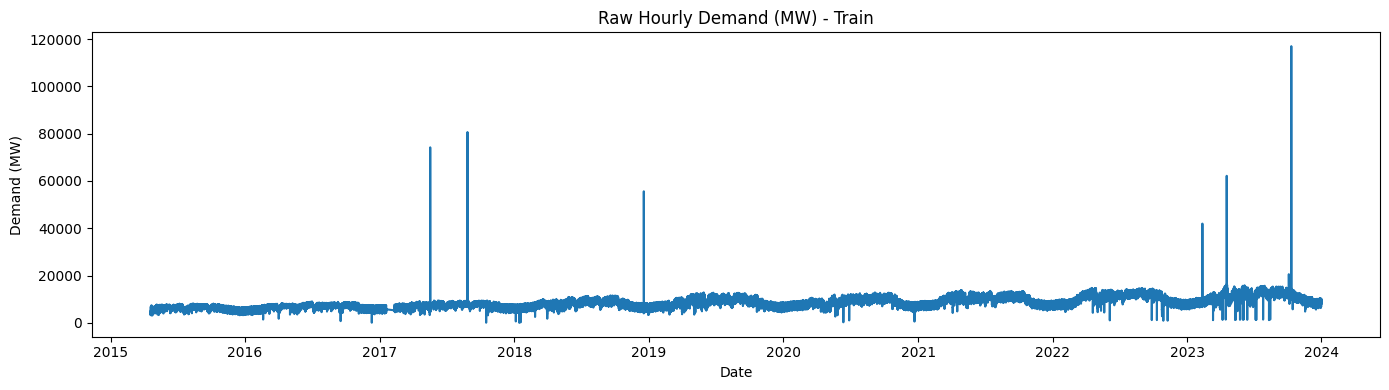

count     76296.000000
mean       8299.308735
std        2445.030687
min           6.000000
25%        6505.000000
50%        7942.000000
75%        9861.000000
max      117000.000000
Name: demand_mw, dtype: float64


In [71]:
plt.figure(figsize=(14, 4))
plt.plot(train_raw['datetime'], train_raw['demand_mw'])
plt.title('Raw Hourly Demand (MW) - Train')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.tight_layout()
plt.show()

print(train_raw['demand_mw'].describe())

From the plot and the data, we can understand that there are massive outliers, where maximum goes to 117000 mw, and the minimum goes as low as 6 mw. These demands are highly unrealistic for a real life data, and have to be treated. 

Here we have picked the IQR method for treating the outliers, where in we will create an upper and lower limit to remove the highly unrealistic demands. Usually a factor of 1.5 is used but here i have used a bigger factor of 3 for our data, because the max and min are ways apart and the mean lies roughly around 8.7k

For a difference, here instead of dropping those rows, i have filled them with the past 5 hour averages, so that the hole created by dropping the rows does'nt affect our coming lag, rolling features

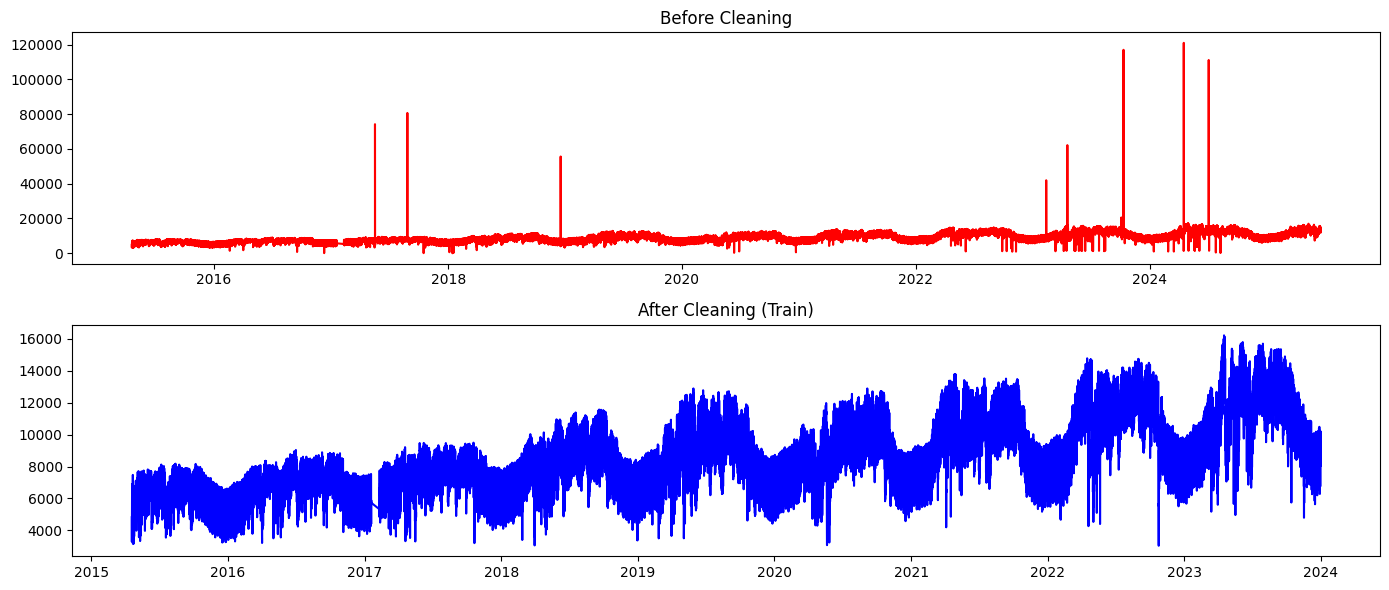

count    76296.000000
mean      8298.602198
std       2365.035631
min       3033.000000
25%       6507.000000
50%       7943.000000
75%       9864.000000
max      16221.000000
Name: demand_mw, dtype: float64
NaNs remaining: 0


In [72]:
Q1 = train_raw['demand_mw'].quantile(0.25)
Q3 = train_raw['demand_mw'].quantile(0.75)
IQR = Q3 - Q1
L = Q1 - 3*IQR
U = Q3 + 3*IQR

for df_ in [train_raw, test_raw]:
    df_.loc[~df_['demand_mw'].between(L, U), 'demand_mw'] = np.nan
    df_.loc[df_['demand_mw'] < 3000, 'demand_mw'] = np.nan
    df_['demand_mw'] = df_['demand_mw'].fillna(
        df_['demand_mw'].rolling(window=5, min_periods=1, center=False).mean()
    ).ffill().bfill()

# Plot before and after
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(demand['datetime'], demand['demand_mw'], color='red')
axes[0].set_title('Before Cleaning')
axes[1].plot(train_raw['datetime'], train_raw['demand_mw'], color='blue')
axes[1].set_title('After Cleaning (Train)')
plt.tight_layout()
plt.show()

print(train_raw['demand_mw'].describe())
print(f"NaNs remaining: {train_raw['demand_mw'].isna().sum()}")

After cleaning, our data has become much better and ready for prediction

generation_mw           0.006780
demand_mw               1.000000
load_shedding           0.247459
gas                     0.563143
liquid_fuel             0.008797
coal                    0.574755
hydro                   0.082808
solar                   0.215251
wind                    0.107519
india_bheramara_hvdc    0.467494
india_tripura           0.694825
india_adani                  NaN
nepal                        NaN
Name: demand_mw, dtype: float64


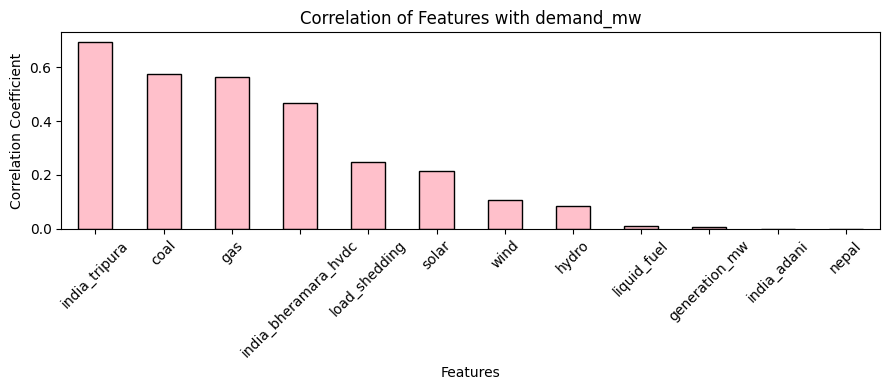

In [73]:
# computing the correlation of the features with demand. 
numeric_cols = train_raw.select_dtypes(include=[np.number]).columns
correlations = train_raw[numeric_cols].corr()['demand_mw']
print(correlations)

corr_features = correlations.drop('demand_mw')
corr_features = corr_features.sort_values(ascending=False)

plt.figure(figsize=(9, 4))
corr_features.plot(kind='bar', color='pink', edgecolor='black')
plt.title('Correlation of Features with demand_mw')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# *Feature Engineering*

Feature engineering is the most critical step. We create four types of features:

(1) calendar features with cyclic encoding to capture daily/weekly/seasonal patterns 

(2) binary flags for domain-specific knowledge like Bangladesh weekends and peak hours

(3) lag features to give the model recent (past hours) demand history

(4) rolling statistics to capture short-term trends

In [ ]:
def add_features(df):
    df = df.sort_values('datetime').reset_index(drop=True)
    df['hour'] = df['datetime'].dt.hour
    df['day_of_week'] = df['datetime'].dt.dayofweek
    df['month'] = df['datetime'].dt.month
    df['year'] = df['datetime'].dt.year

    # Calendar sine/cosine encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # Binary flags
    df['is_fri_sat'] = df['day_of_week'].isin([4, 5]).astype(int)
    df['peak_hours'] = df['hour'].apply(lambda x: 1 if 17 <= x <= 23 else 0)
    df['peak_month'] = df['month'].isin([5,6,7,8,9,10]).astype(int)

    # Lag features
    df['lag_1h']  = df['demand_mw'].shift(1)
    df['lag_2h']  = df['demand_mw'].shift(2)
    df['lag_3h']  = df['demand_mw'].shift(3)
    df['lag_24h'] = df['demand_mw'].shift(24)

    # Rolling features
    df['rolling_2h'] = df['demand_mw'].shift(1).rolling(2).mean()
    df['rolling_6h'] = df['demand_mw'].shift(1).rolling(6).mean()

    # Target
    df['target'] = df['demand_mw'].shift(-1)
    return df

train_raw = add_features(train_raw)
test_raw  = add_features(test_raw)

print(train_raw.shape, test_raw.shape)
print(train_raw[['datetime','demand_mw','lag_1h','lag_2h','lag_3h','hour','target']].head(15))

(76296, 39) (8784, 39)
              datetime  demand_mw  lag_1h  lag_2h  lag_3h  hour  target
0  2015-04-19 00:00:00     4821.0     NaN     NaN     NaN     0  3612.0
1  2015-04-19 01:00:00     3612.0  4821.0     NaN     NaN     1  3727.0
2  2015-04-19 02:00:00     3727.0  3612.0  4821.0     NaN     2  3632.0
3  2015-04-19 03:00:00     3632.0  3727.0  3612.0  4821.0     3  3641.0
4  2015-04-19 04:00:00     3641.0  3632.0  3727.0  3612.0     4  3283.0
5  2015-04-19 05:00:00     3283.0  3641.0  3632.0  3727.0     5  3444.0
6  2015-04-19 06:00:00     3444.0  3283.0  3641.0  3632.0     6  3592.0
7  2015-04-19 07:00:00     3592.0  3444.0  3283.0  3641.0     7  4049.0
8  2015-04-19 08:00:00     4049.0  3592.0  3444.0  3283.0     8  4488.0
9  2015-04-19 09:00:00     4488.0  4049.0  3592.0  3444.0     9  4803.0
10 2015-04-19 10:00:00     4803.0  4488.0  4049.0  3592.0    10  5029.0
11 2015-04-19 11:00:00     5029.0  4803.0  4488.0  4049.0    11  5284.0
12 2015-04-19 12:00:00     5284.0  5029.0

# *Understanding the logic behind the engineered features*

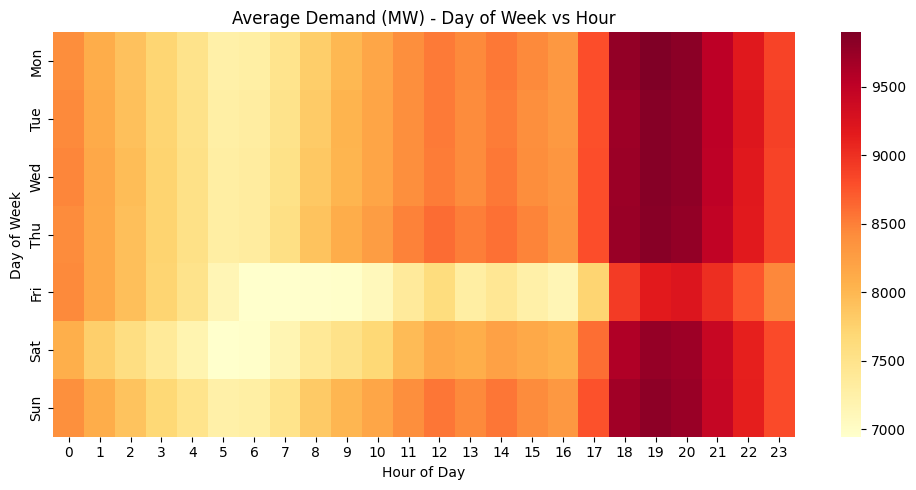

In [75]:
import seaborn as sns
pivot = train_raw.groupby(['day_of_week', 'hour'])['demand_mw'].mean().unstack()
pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
plt.figure(figsize=(10, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, linewidths=0)
plt.title('Average Demand (MW) - Day of Week vs Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

from the above heat map, we can see that 17:00-23:00 are the peak hours of electricity demand 
and 1 am to 8 am is comparitively lower 

and it's also visible that friday and saturday have lower demands than the other days, which comes from the fact that friday and saturday is weekend in Bangladesh and the factories, offices, schools are closed. 

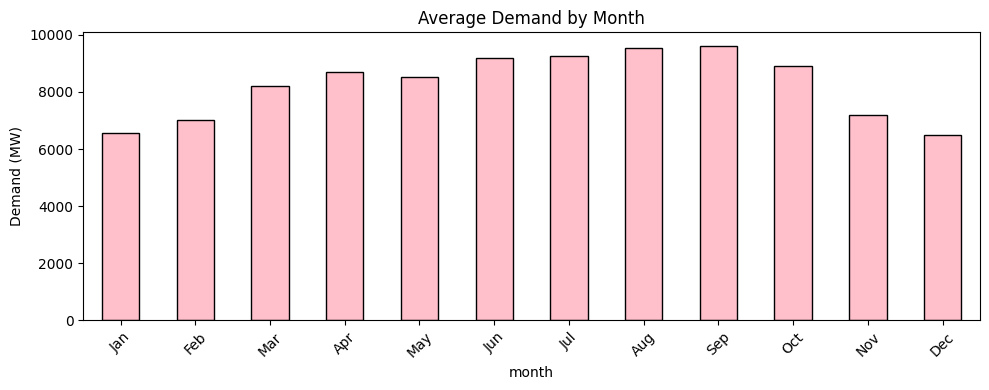

In [76]:
plt.figure(figsize=(10, 4))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
train_raw.groupby('month')['demand_mw'].mean().plot(kind='bar', color='pink', edgecolor='black')
plt.xticks(range(12), month_names, rotation=45)
plt.title('Average Demand by Month')
plt.ylabel('Demand (MW)')
plt.tight_layout()
plt.show()

months june-october are the peak months of electricity demand in Bangladesh


In [ ]:
# Test which lags actually correlate with target
lag_cols = ['lag_1h','lag_2h','lag_3h','lag_24h']
for col in lag_cols:
    corr = train_raw[col].corr(train_raw['target'])
    print(f"{col}: {corr:.4f}")

lag_1h: 0.9504
lag_2h: 0.9159
lag_3h: 0.8818
lag_24h: 0.9289
lag_48h: 0.9048
lag_168h: 0.8703


As expected, lag_1h shows the highest correlation with target (~0.95), confirming that the most recent demand is the strongest predictor. Correlation drops gradually for longer lags, validating our feature selection.

# *Weather Features*

In [78]:
weather = pd.read_excel('weather_data.xlsx', header=2)
print(weather.columns.tolist())
print(weather.shape)
print(weather.dtypes)

['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']
(107305, 10)
Unnamed: 0    object
Unnamed: 1    object
Unnamed: 2    object
Unnamed: 3    object
Unnamed: 4    object
Unnamed: 5    object
Unnamed: 6    object
Unnamed: 7    object
Unnamed: 8    object
Unnamed: 9    object
dtype: object


In [79]:
weather.columns = ['time', 'temperature', 'humidity', 'apparent_temp',
                   'precipitation', 'dew_point', 'soil_temp', 
                   'wind_direction', 'cloud_cover', 'sunshine_duration']

weather = weather[weather['time'] != 'time'].reset_index(drop=True)
weather['time'] = pd.to_datetime(weather['time'])

for col in ['temperature', 'humidity', 'apparent_temp', 'precipitation', 
            'dew_point', 'soil_temp', 'wind_direction', 'cloud_cover', 'sunshine_duration']:
    weather[col] = pd.to_numeric(weather[col], errors='coerce')

print(weather.dtypes)

weather = weather[['time', 'temperature', 'humidity', 'apparent_temp',
                   'precipitation', 'dew_point', 'soil_temp', 
                   'wind_direction', 'cloud_cover', 'sunshine_duration']]

print(weather.shape)

time                 datetime64[us]
temperature                 float64
humidity                      int64
apparent_temp               float64
precipitation               float64
dew_point                   float64
soil_temp                   float64
wind_direction                int64
cloud_cover                   int64
sunshine_duration           float64
dtype: object
(107304, 10)


In [80]:
weather = weather.rename(columns={'time': 'datetime'})

weather_cols = ['temperature', 'humidity', 'apparent_temp', 'precipitation',
                'dew_point', 'soil_temp', 'wind_direction',
                'cloud_cover', 'sunshine_duration']

train_raw = train_raw.drop(columns=[c for c in weather_cols if c in train_raw.columns], errors='ignore')
test_raw  = test_raw.drop(columns=[c for c in weather_cols if c in test_raw.columns], errors='ignore')

train_raw = train_raw.merge(weather, on='datetime', how='left')
test_raw  = test_raw.merge(weather, on='datetime', how='left')

# Interpolate separately - no cross boundary leakage
train_raw[weather_cols] = train_raw[weather_cols].interpolate(method='linear').ffill()
test_raw[weather_cols]  = test_raw[weather_cols].interpolate(method='linear').ffill()

print(train_raw.shape, test_raw.shape)
print(train_raw[['datetime', 'temperature', 'humidity', 'precipitation']].head(5))

(76296, 48) (8784, 48)
             datetime  temperature  humidity  precipitation
0 2015-04-19 00:00:00         25.7        87            0.0
1 2015-04-19 01:00:00         25.3        88            0.0
2 2015-04-19 02:00:00         24.9        90            0.0
3 2015-04-19 03:00:00         25.0        90            0.0
4 2015-04-19 04:00:00         25.2        91            0.0


Hourly weather data is merged on datetime. Weather features like temperature, precipitation and humidity are key drivers of electricity demand, air conditioning and heating loads are highly weather-dependent. Interpolation is performed separately on train and test to avoid cross-boundary leakage.

# *Economic Features*

In [ ]:
economic = pd.read_csv('economic_full_1.csv')

eco_filtered = economic[economic['Indicator Name'].isin([
    'Electric power consumption (kWh per capita)',
])]

eco_t = eco_filtered.set_index('Indicator Name').T
eco_t.index.name = 'year'
eco_t = eco_t.reset_index()
eco_t['year'] = pd.to_numeric(eco_t['year'], errors='coerce')
eco_t = eco_t.dropna(subset=['year'])
eco_t['year'] = eco_t['year'].astype(int)

eco_t.columns = ['year', 'power_consumption_per_capita']

eco_cols = ['power_consumption_per_capita']

eco_t[eco_cols[0]] = pd.to_numeric(eco_t[eco_cols[0]], errors='coerce')

train_raw = train_raw.drop(columns=[c for c in eco_cols if c in train_raw.columns], errors='ignore')
test_raw  = test_raw.drop(columns=[c for c in eco_cols if c in test_raw.columns], errors='ignore')

train_raw = train_raw.merge(eco_t, on='year', how='left')
test_raw  = test_raw.merge(eco_t, on='year', how='left')

train_raw[eco_cols] = train_raw.sort_values('datetime')[eco_cols].ffill()
test_raw[eco_cols]  = test_raw.sort_values('datetime')[eco_cols].ffill()

print(train_raw.shape, test_raw.shape)
print(eco_t.head())


The years were present as columns instead of rows, for that case transpose is taken. 
Annual economic indicators are merged on year. These capture the long-term structural growth in Bangladesh's electricity demand. Since these are annual figures, they remain constant within each year.

In [147]:
feature_cols = ['load_shedding','solar','coal', 'day_sin','day_cos','month_cos','month_sin','hour_cos','hour_sin',
                 'is_fri_sat', 'peak_hours',
                'peak_month','lag_1h', 'lag_2h', 'lag_3h','lag_24h', 'rolling_2h',
                'rolling_6h','temperature', 'humidity', 'precipitation', 'cloud_cover',
                'power_consumption_per_capita']

required_cols = feature_cols + ['target']

train = train_raw.dropna(subset=required_cols).copy()
test  = test_raw.dropna(subset=required_cols).copy()

X_train = train[feature_cols]
y_train = train['target']
X_test  = test[feature_cols]
y_test  = test['target']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (55049, 23), Test: (8759, 23)


Final feature set is selected based on domain relevance and correlation analysis. Redundant economic indicators (GDP, manufacturing share) are excluded as they are colinear with power_consumption_per_capita.

# *Model Selection*

In [148]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score

models = {
    'LightGBM': LGBMRegressor(
        n_estimators=2000, learning_rate=0.02, max_depth=8,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8, verbose=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=2000, learning_rate=0.02, max_depth=8,
        subsample=0.8, colsample_bytree=0.8, verbosity=0
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=500, max_depth=12, n_jobs=-1, random_state=42
    )
}

results = {}
predictions = {}

for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    y_pred_m = mdl.predict(X_test)
    results[name] = {
        'MAPE': round(mean_absolute_percentage_error(y_test, y_pred_m) * 100, 4),
        'MAE':  round(mean_absolute_error(y_test, y_pred_m), 2),
        'R2':   round(r2_score(y_test, y_pred_m), 4)
    }
    predictions[name] = y_pred_m

print(f"LightGBM MAPE     - {results['LightGBM']['MAPE']}%")
print(f"XGBoost MAPE      - {results['XGBoost']['MAPE']}%")
print(f"Random Forest MAPE - {results['Random Forest']['MAPE']}%")

best_name = min(results, key=lambda x: results[x]['MAPE'])
y_pred = predictions[best_name]
model = models[best_name]

print("------------------------------------------------------------------")

print(f"Best Model  - {best_name}")
print(f"MAPE        - {results[best_name]['MAPE']}%")
print(f"R2          - {results[best_name]['R2']}")
print(f"MAE         - {results[best_name]['MAE']} MW")

LightGBM MAPE     - 2.4682%
XGBoost MAPE      - 2.4735%
Random Forest MAPE - 2.8172%
------------------------------------------------------------------
Best Model  - LightGBM
MAPE        - 2.4682%
R2          - 0.9744
MAE         - 273.9 MW


All three models perform well, with LightGBM narrowly winning at 2.46% MAPE. The small gap between LightGBM (2.46%) and XGBoost (2.47%) suggests the feature set is strong and both models are capturing the underlying patterns effectively.

# *Prediction/Residual Graphs*

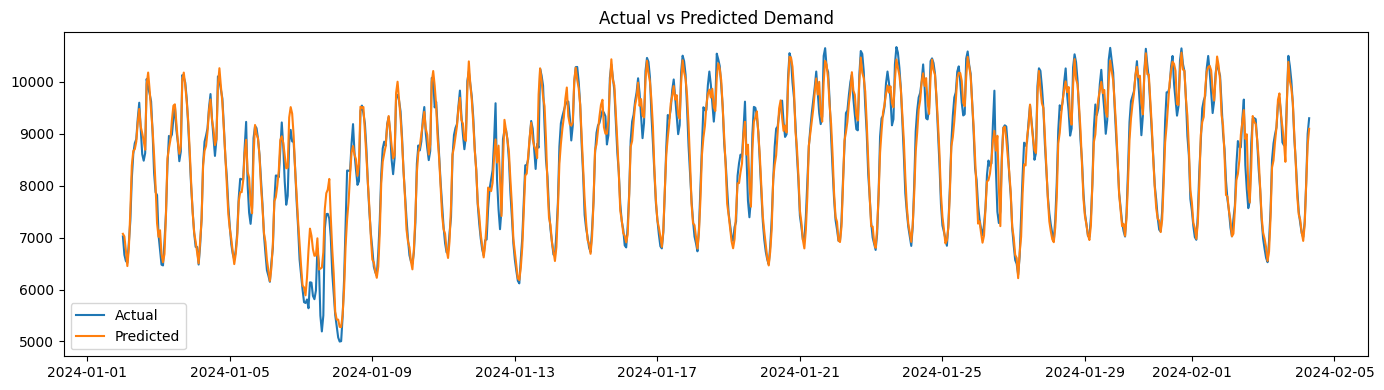

In [149]:
sample = test.iloc[:800]
plt.figure(figsize=(14,4))
plt.plot(sample['datetime'], y_test.iloc[:800].values, label='Actual')
plt.plot(sample['datetime'], y_pred[:800], label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Demand')
plt.tight_layout()
plt.show()

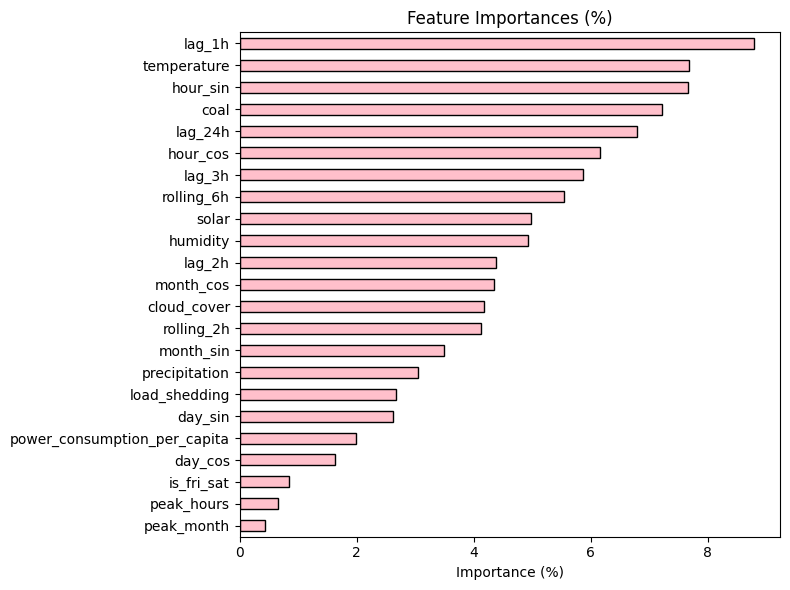

lag_1h                          8.79
temperature                     7.69
hour_sin                        7.66
coal                            7.22
lag_24h                         6.80
hour_cos                        6.16
lag_3h                          5.86
rolling_6h                      5.54
solar                           4.97
humidity                        4.93
lag_2h                          4.38
month_cos                       4.34
cloud_cover                     4.17
rolling_2h                      4.12
month_sin                       3.48
precipitation                   3.05
load_shedding                   2.67
day_sin                         2.62
power_consumption_per_capita    1.99
day_cos                         1.63
is_fri_sat                      0.84
peak_hours                      0.65
peak_month                      0.44
dtype: float64


In [150]:
importances = pd.Series(model.feature_importances_,
                        index=feature_cols)
importances = (importances / importances.sum() * 100).sort_values(ascending=False)

importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances_sorted.plot(kind='barh', color='pink', edgecolor='black')
plt.title('Feature Importances (%)')
plt.xlabel('Importance (%)')
plt.tight_layout()
plt.show()

print(importances.round(2))

lag_1h dominates feature importance at ~9%, confirming that the most recent hour is the strongest predictor of next-hour demand. 

Notably, temperature and hour_sin rank 2nd and 3rd at ~7.5% each, reflecting that weather and time of day are nearly as important as recent demand history, which makes strong domain sense for electricity forecasting.

coal ranking 4th (~7%) is interesting, it acts as a proxy for industrial demand, capturing the supply-side structure. 

lag_24h at ~6.7% confirms strong same-hour-yesterday patterns, validating the daily seasonality in Bangladesh's demand cycle.

The binary flags is_fri_sat, peak_hours, and peak_month rank lowest, not because they are unimportant, but because their information is already partially captured by the cyclic calendar features (hour_sin, hour_cos, month_sin, month_cos) and the model learns to rely on the continuous encodings more.

Overall the importance is well spread across all 23 features with no single feature overwhelming the rest, indicating a healthy and diverse feature set.

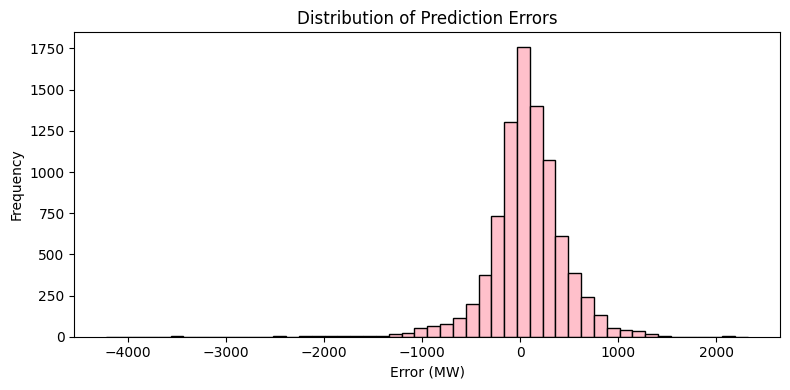

In [151]:
plt.figure(figsize=(8, 4))
residuals = y_test.values - y_pred
plt.hist(residuals, bins=50, color='pink', edgecolor='black')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error (MW)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

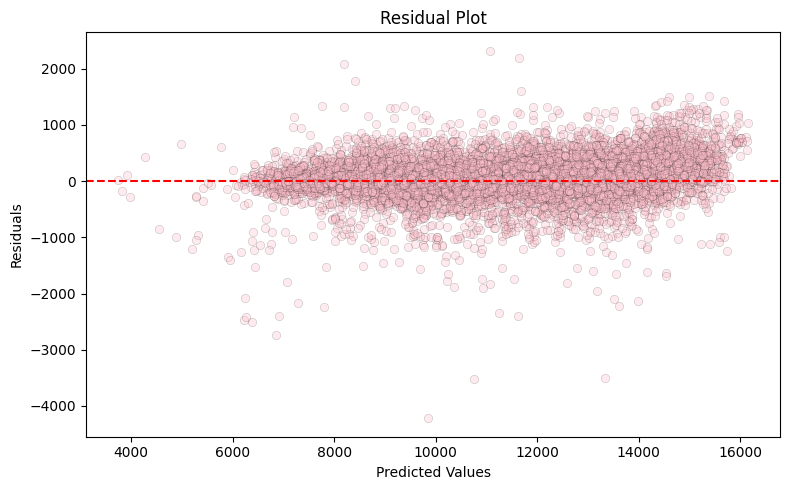

In [153]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color='pink', edgecolors='black', linewidths=0.3)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

The residual distribution is approximately normal and centered near zero, indicating no systematic bias. The residual scatter plot shows uniform spread across predicted values, suggesting the model performs consistently across low and high demand periods.

# *Conclusion*
In this notebook, we built an end-to-end pipeline to forecast hourly electricity demand for Bangladesh for the year 2024 using classical machine learning, existing data sets, engineered features and tree-based models.

The final model --> LightGBM --> achieves a MAPE of 2.46% and an R² of 0.97, meaning the model explains 97% of the variance in electricity demand and stays within ~2.5% of the actual value on average.
